# EHT Black Hole: Closure-Only VLBI Imaging

This notebook demonstrates the key result from **Chael et al. (2018), ApJ 857:23**:
closure-only imaging is robust to station-based gain errors, while traditional
visibility imaging fails catastrophically.

We compare two imaging strategies on synthetic EHT M87* data:

| Method | Data terms | Gain-robust? |
|--------|-----------|-------------|
| **Visibility RML** | Complex visibilities | No |
| **Closure-only** | Closure phases + log closure amplitudes | **Yes** |

Each method is tested on both **calibrated** and **gain-corrupted** observations.

By default, this notebook loads **precomputed results** from `evaluation/reference_outputs/`
and runs in seconds. To run reconstruction from scratch, uncomment the marked cells.

In [1]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt

# Task root (one level up from notebooks/)
TASK_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, TASK_DIR)

from src.preprocessing import load_observation, load_metadata
from src.visualization import (
    compute_metrics, print_metrics_table, plot_uv_coverage,
    plot_image, plot_comparison, plot_gain_robustness
)

REF_DIR = os.path.join(TASK_DIR, 'evaluation', 'reference_outputs')
DATA_DIR = os.path.join(TASK_DIR, 'data')

%matplotlib inline
plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})
print('Setup complete.')

Setup complete.


## 1. Load Data

The dataset contains 421 baselines from a 7-station EHT 2017 array observing
a synthetic M87*-like crescent ring at 230 GHz. Two sets of complex visibilities
are provided:
- **Calibrated**: perfect gain calibration
- **Corrupted**: 20% station-based gain amplitude errors + random phase errors

Closure quantities (269 closure phases, 233 log closure amplitudes) are
pre-computed per time scan.

In [2]:
obs = load_observation(DATA_DIR)
meta = load_metadata(DATA_DIR)

N = meta['N']
psize = meta['pixel_size_rad']
pixel_uas = meta['pixel_size_uas']
total_flux = meta['total_flux']
fov = N * pixel_uas
hw = fov / 2

print(f'Image grid:      {N} x {N} pixels, {pixel_uas} uas/pixel')
print(f'Field of view:   {fov} uas')
print(f'Total flux:      {total_flux} Jy')
print(f'Baselines:       {len(obs["uv_coords"])}')
print(f'Stations:        {meta["n_stations"]} ({meta.get("station_names", "?")})')
print(f'Closure phases:  {len(obs["cp_values_deg"])}')
print(f'Log closure amps: {len(obs["lca_values"])}')
print(f'Gain error:      {meta["gain_amp_error"]*100:.0f}% amplitude')

Image grid:      64 x 64 pixels, 2.0 uas/pixel
Field of view:   128.0 uas
Total flux:      0.6 Jy
Baselines:       421
Stations:        7 (['ALMA', 'APEX', 'JCMT', 'LMT', 'PV', 'SMA', 'SMT'])
Closure phases:  269
Log closure amps: 233
Gain error:      20% amplitude


## 2. Ground Truth & UV Coverage

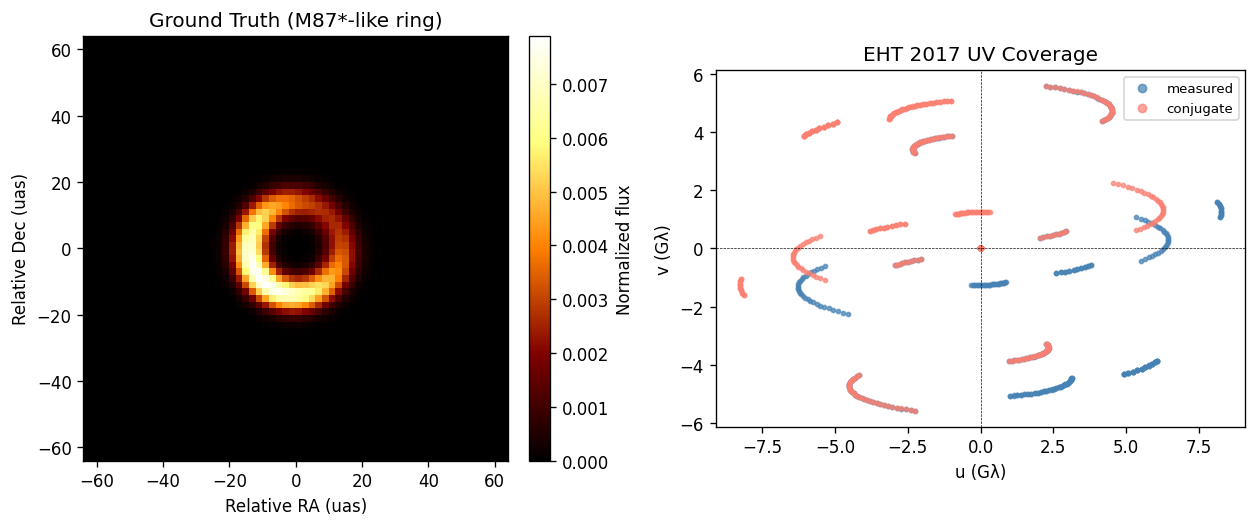

In [3]:
gt = np.load(os.path.join(REF_DIR, 'ground_truth.npy'))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Ground truth
ax = axes[0]
im = ax.imshow(gt, cmap='afmhot', origin='lower', extent=[-hw, hw, -hw, hw])
ax.set_xlabel('Relative RA (uas)')
ax.set_ylabel('Relative Dec (uas)')
ax.set_title('Ground Truth (M87*-like ring)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Normalized flux')

# UV coverage
plot_uv_coverage(obs['uv_coords'], title='EHT 2017 UV Coverage', ax=axes[1])

plt.tight_layout()
plt.show()

## 3. Closure Quantities: Gain Invariance

Closure phases and log closure amplitudes cancel station-based gains:
- **Closure phase**: $\phi_C = \arg(V_{ij} V_{jk} V_{ki})$ -- gains cancel in the triple product
- **Log closure amplitude**: $\log|V_{ij}| + \log|V_{kl}| - \log|V_{ik}| - \log|V_{jl}|$ -- gain factors cancel

Below we show that visibility amplitudes are corrupted by gains, but closure
quantities remain nearly identical between calibrated and corrupted data.

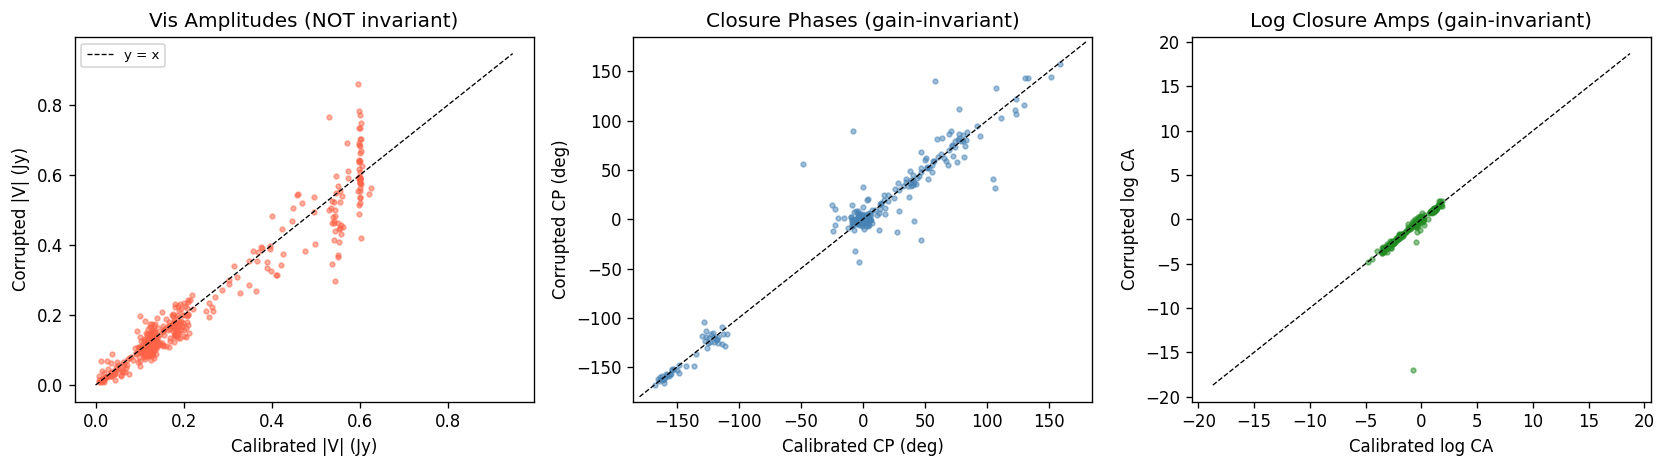

Vis amplitude RMSD:   0.0495 Jy  (large)
Closure phase RMSD:   15.77 deg  (noise-level)
Log closure amp RMSD: 1.0999     (noise-level)


In [4]:
# Visibility amplitudes are NOT gain-invariant
amp_cal = np.abs(obs['vis_cal'])
amp_cor = np.abs(obs['vis_corrupt'])

# Closure phases ARE gain-invariant (up to thermal noise)
cp_cal = obs['cp_values_deg']
cp_cor = obs['cp_corrupt_values_deg']

# Log closure amplitudes ARE gain-invariant (up to thermal noise)
lca_cal = obs['lca_values']
lca_cor = obs['lca_corrupt_values']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Amplitudes
ax = axes[0]
ax.scatter(amp_cal, amp_cor, s=8, alpha=0.5, c='tomato')
lim = max(amp_cal.max(), amp_cor.max()) * 1.1
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='y = x')
ax.set_xlabel('Calibrated |V| (Jy)')
ax.set_ylabel('Corrupted |V| (Jy)')
ax.set_title('Vis Amplitudes (NOT invariant)')
ax.legend(fontsize=8)

# Closure phases
ax = axes[1]
ax.scatter(cp_cal, cp_cor, s=8, alpha=0.5, c='steelblue')
ax.plot([-180, 180], [-180, 180], 'k--', lw=0.8)
ax.set_xlabel('Calibrated CP (deg)')
ax.set_ylabel('Corrupted CP (deg)')
ax.set_title('Closure Phases (gain-invariant)')
ax.set_xlim(-185, 185); ax.set_ylim(-185, 185)

# Log closure amplitudes
ax = axes[2]
lim_lca = max(np.abs(lca_cal).max(), np.abs(lca_cor).max()) * 1.1
ax.scatter(lca_cal, lca_cor, s=8, alpha=0.5, c='forestgreen')
ax.plot([-lim_lca, lim_lca], [-lim_lca, lim_lca], 'k--', lw=0.8)
ax.set_xlabel('Calibrated log CA')
ax.set_ylabel('Corrupted log CA')
ax.set_title('Log Closure Amps (gain-invariant)')

plt.tight_layout()
plt.show()

print(f'Vis amplitude RMSD:   {np.sqrt(np.mean((amp_cal - amp_cor)**2)):.4f} Jy  (large)')
print(f'Closure phase RMSD:   {np.sqrt(np.mean((cp_cal - cp_cor)**2)):.2f} deg  (noise-level)')
print(f'Log closure amp RMSD: {np.sqrt(np.mean((lca_cal - lca_cor)**2)):.4f}     (noise-level)')

## 4. Image Reconstruction

We compare two methods on both calibrated and corrupted data:
- **Vis RML**: minimizes visibility chi-squared + entropy regularizers
- **Closure-only**: minimizes closure phase + log closure amplitude chi-squared + entropy regularizers

Both use Gull-Skilling entropy (`gs=1`) and simple entropy (`simple=10`) as regularizers,
optimized with L-BFGS-B in log-image space (matching ehtim's default).

**By default, this loads precomputed results.** Uncomment the next cell to run from scratch (~2 min).

In [5]:
# --- Load precomputed results (fast, runs in seconds) ---
results = {}

# Our cleaned code results (from main.py output)
output_dir = os.path.join(TASK_DIR, 'output')
if os.path.exists(os.path.join(output_dir, 'metrics.json')):
    with open(os.path.join(output_dir, 'metrics.json')) as f:
        saved_metrics = json.load(f)
    results['Closure-only (corrupt)'] = np.load(
        os.path.join(output_dir, 'reconstruction.npy'))
    print('Loaded output/reconstruction.npy')

# ehtim reference results
ref_files = {
    'Vis RML (cal)':          'vis_rml_cal.npy',
    'Vis RML (corrupt)':      'vis_rml_corrupt.npy',
    'Closure-only (cal)':     'closure-only_cal.npy',
    'Closure-only (corrupt, ehtim)': 'closure-only_corrupt.npy',
}
ehtim_results = {}
for name, fname in ref_files.items():
    path = os.path.join(REF_DIR, fname)
    if os.path.exists(path):
        ehtim_results[name] = np.load(path)

print(f'Loaded {len(ehtim_results)} ehtim reference images')
print(f'Loaded {len(results)} cleaned-code results')

Loaded output/reconstruction.npy
Loaded 4 ehtim reference images
Loaded 1 cleaned-code results


In [6]:
# --- Uncomment to run reconstruction from scratch (~2 min) ---
from src.physics_model import ClosureForwardModel
from src.solvers import ClosureRMLSolver

# Build forward model
model = ClosureForwardModel(
    uv_coords=obs['uv_coords'], N=N, pixel_size_rad=psize,
    triangles=np.zeros((0, 3), dtype=int),
    quadrangles=np.zeros((0, 4), dtype=int),
)

# Gaussian prior
uas_to_rad = np.pi / (180 * 3600 * 1e6)
fwhm_rad = 20.0 * uas_to_rad
sigma_prior = fwhm_rad / (2 * np.sqrt(2 * np.log(2)))
coords_rad = (np.arange(N) - N / 2) * psize
xx, yy = np.meshgrid(coords_rad, coords_rad)
prior = np.exp(-(xx**2 + yy**2) / (2 * sigma_prior**2))
prior *= total_flux / prior.sum()

reg = {'gs': 1, 'simple': 10}

# Calibrated closure data
obs_data_cal = {
    'vis_obs': obs['vis_cal'], 'sigma_vis': obs['sigma_vis'],
    'cp_values_deg': obs['cp_values_deg'], 'cp_sigmas_deg': obs['cp_sigmas_deg'],
    'cp_u1': obs['cp_u1'], 'cp_u2': obs['cp_u2'], 'cp_u3': obs['cp_u3'],
    'lca_values': obs['lca_values'], 'lca_sigmas': obs['lca_sigmas'],
    'lca_u1': obs['lca_u1'], 'lca_u2': obs['lca_u2'],
    'lca_u3': obs['lca_u3'], 'lca_u4': obs['lca_u4'],
}
# Corrupted closure data
obs_data_corrupt = {
    'vis_obs': obs['vis_corrupt'], 'sigma_vis': obs['sigma_vis'],
    'cp_values_deg': obs['cp_corrupt_values_deg'],
    'cp_sigmas_deg': obs['cp_corrupt_sigmas_deg'],
    'cp_u1': obs['cp_u1'], 'cp_u2': obs['cp_u2'], 'cp_u3': obs['cp_u3'],
    'lca_values': obs['lca_corrupt_values'],
    'lca_sigmas': obs['lca_corrupt_sigmas'],
    'lca_u1': obs['lca_u1'], 'lca_u2': obs['lca_u2'],
    'lca_u3': obs['lca_u3'], 'lca_u4': obs['lca_u4'],
}

print('Reconstructing...')
results = {}

print('  [1/4] Vis RML (calibrated) ...')
solver = ClosureRMLSolver(data_terms={'vis': 100}, reg_terms=reg, prior=prior)
results['Vis RML (cal)'] = solver.reconstruct(model, obs_data_cal, x0=prior)

print('  [2/4] Vis RML (corrupted) ...')
solver = ClosureRMLSolver(data_terms={'vis': 100}, reg_terms=reg, prior=prior)
results['Vis RML (corrupt)'] = solver.reconstruct(model, obs_data_corrupt, x0=prior)

print('  [3/4] Closure-only (calibrated) ...')
solver = ClosureRMLSolver(
    data_terms={'cphase': 50, 'logcamp': 50}, reg_terms=reg, prior=prior)
results['Closure-only (cal)'] = solver.reconstruct(model, obs_data_cal, x0=prior)

print('  [4/4] Closure-only (corrupted) ...')
solver = ClosureRMLSolver(
    data_terms={'cphase': 50, 'logcamp': 50}, reg_terms=reg, prior=prior)
results['Closure-only (corrupt)'] = solver.reconstruct(model, obs_data_corrupt, x0=prior)

print('Done!')

Reconstructing...
  [1/4] Vis RML (calibrated) ...
  [2/4] Vis RML (corrupted) ...


/home/groot/Documents/PKUlab/imaging-101/tasks/eht_black_hole_original/src/solvers.py:64: RuntimeWarning: divide by zero encountered in log
  val = float(np.sum(imvec - priorvec - imvec * np.log(imvec / priorvec)))
/home/groot/Documents/PKUlab/imaging-101/tasks/eht_black_hole_original/src/solvers.py:64: RuntimeWarning: invalid value encountered in multiply
  val = float(np.sum(imvec - priorvec - imvec * np.log(imvec / priorvec)))
/home/groot/Documents/PKUlab/imaging-101/tasks/eht_black_hole_original/src/solvers.py:65: RuntimeWarning: divide by zero encountered in log
  grad = -np.log(imvec / priorvec)
/home/groot/Documents/PKUlab/imaging-101/tasks/eht_black_hole_original/src/solvers.py:94: RuntimeWarning: divide by zero encountered in log
  val = float(-np.sum(imvec * np.log(imvec / priorvec)))
/home/groot/Documents/PKUlab/imaging-101/tasks/eht_black_hole_original/src/solvers.py:94: RuntimeWarning: invalid value encountered in multiply
  val = float(-np.sum(imvec * np.log(imvec / prior

  [3/4] Closure-only (calibrated) ...
  [4/4] Closure-only (corrupted) ...
Done!


## 5. Results: Calibrated Data

On perfectly calibrated data, both methods produce reasonable reconstructions.
Vis RML has the best fidelity since it uses the most information.

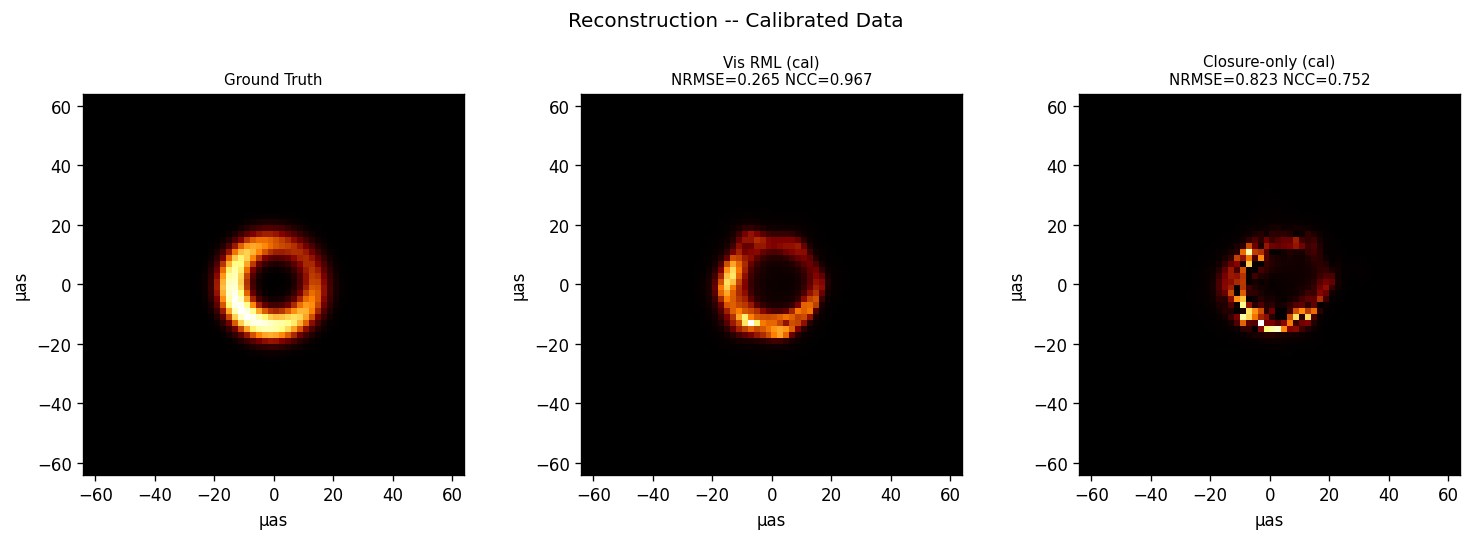


Method                            NRMSE      NCC   DynRange
----------------------------------------------------------
Vis RML (cal)                    0.2648   0.9669      48.92
Closure-only (cal)               0.8226   0.7523      23.42


In [7]:
cal_images = {k: v for k, v in ehtim_results.items() if 'cal' in k and 'corrupt' not in k}
cal_metrics = {name: compute_metrics(img, gt) for name, img in cal_images.items()}

fig = plot_comparison(cal_images, gt, cal_metrics, pixel_size_uas=pixel_uas,
                      suptitle='Reconstruction -- Calibrated Data')
plt.show()

print()
print_metrics_table(cal_metrics)

## 6. Results: Gain-Corrupted Data

With 20% station-based gain errors:
- **Vis RML fails catastrophically** (NCC ~ 0) because complex visibilities are corrupted
- **Closure-only remains robust** (NCC > 0.6) because closure quantities are gain-invariant

This is the central result of Chael et al. (2018).

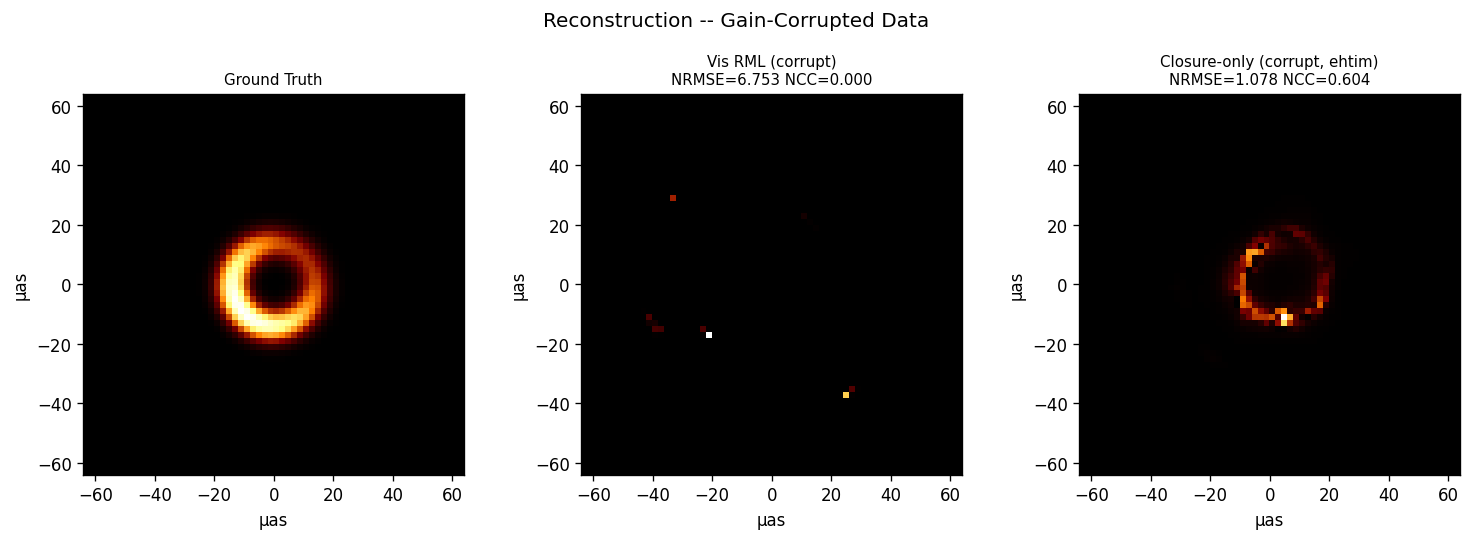


Method                            NRMSE      NCC   DynRange
----------------------------------------------------------
Vis RML (corrupt)                6.7528   0.0001      49.50
Closure-only (corrupt, ehtim)    1.0778   0.6044      26.71


In [8]:
cor_images = {k: v for k, v in ehtim_results.items() if 'corrupt' in k}
cor_metrics = {name: compute_metrics(img, gt) for name, img in cor_images.items()}

fig = plot_comparison(cor_images, gt, cor_metrics, pixel_size_uas=pixel_uas,
                      suptitle='Reconstruction -- Gain-Corrupted Data')
plt.show()

print()
print_metrics_table(cor_metrics)

## 7. Side-by-Side: Calibrated vs Corrupted

Direct comparison showing gain robustness. Top row: calibrated, bottom row: corrupted.

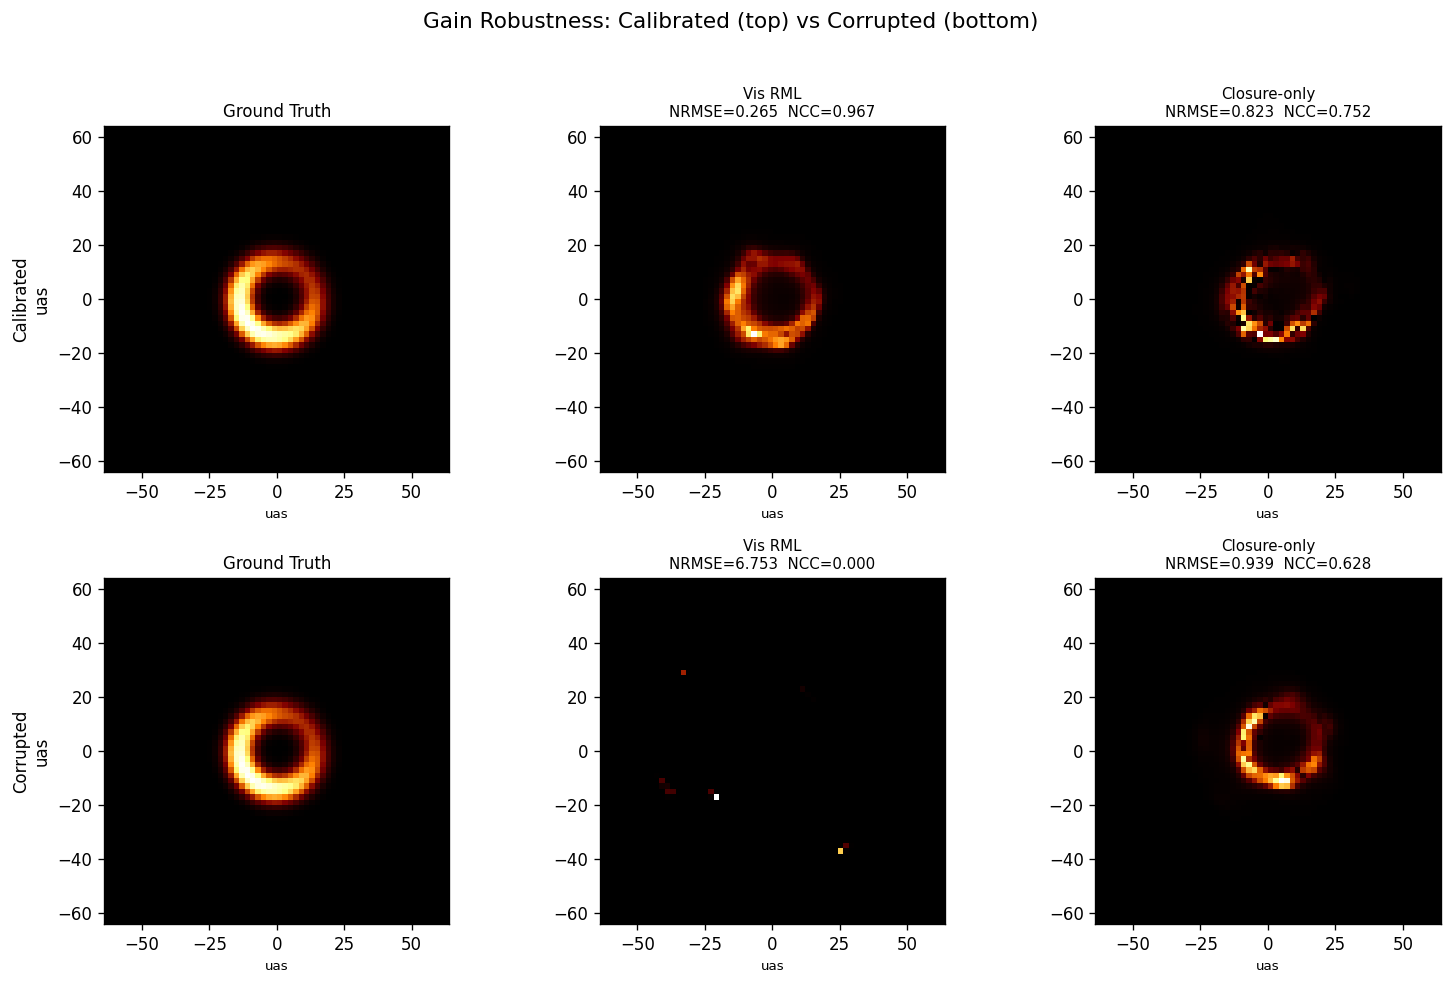

In [9]:
methods = ['Vis RML', 'Closure-only']

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for row, (label, suffix) in enumerate([('Calibrated', '(cal)'), ('Corrupted', '(corrupt)')]):
    # Ground truth
    axes[row, 0].imshow(gt, cmap='afmhot', origin='lower', extent=[-hw, hw, -hw, hw])
    axes[row, 0].set_title('Ground Truth', fontsize=10)
    axes[row, 0].set_ylabel(f'{label}\nuas', fontsize=10)

    for j, method in enumerate(methods):
        key = f'{method} {suffix}'
        # Try ehtim results first, fall back to our results
        img = ehtim_results.get(key, results.get(key))
        if img is None:
            axes[row, j+1].text(0.5, 0.5, 'Not available', ha='center', va='center',
                               transform=axes[row, j+1].transAxes)
            continue
        m = compute_metrics(img, gt)
        axes[row, j+1].imshow(img, cmap='afmhot', origin='lower',
                              extent=[-hw, hw, -hw, hw], vmin=0, vmax=img.max())
        axes[row, j+1].set_title(f'{method}\nNRMSE={m["nrmse"]:.3f}  NCC={m["ncc"]:.3f}',
                                 fontsize=9)

for ax in axes.flat:
    ax.set_xlabel('uas', fontsize=8)

fig.suptitle('Gain Robustness: Calibrated (top) vs Corrupted (bottom)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Summary Metrics

Comparing our cleaned implementation against ehtim reference.

In [10]:
# ehtim reference metrics
with open(os.path.join(REF_DIR, 'metrics.json')) as f:
    ehtim_metrics = json.load(f)

print('ehtim Reference Metrics:')
print(f'{"Method":<30s} {"NRMSE":>8s} {"NCC":>8s}')
print('-' * 48)
for name, m in ehtim_metrics.items():
    print(f'{name:<30s} {m["nrmse"]:>8.4f} {m["ncc"]:>8.4f}')

# Our cleaned code metrics
if os.path.exists(os.path.join(output_dir, 'metrics.json')):
    with open(os.path.join(output_dir, 'metrics.json')) as f:
        our_metrics = json.load(f)
    print()
    print('Cleaned Code Metrics:')
    print(f'{"Method":<30s} {"NRMSE":>8s} {"NCC":>8s}')
    print('-' * 48)
    for name, m in our_metrics.items():
        print(f'{name:<30s} {m["nrmse"]:>8.4f} {m["ncc"]:>8.4f}')

ehtim Reference Metrics:
Method                            NRMSE      NCC
------------------------------------------------
Vis RML (cal)                    0.2648   0.9669
Amp+CP (cal)                     0.7043   0.7630
Closure-only (cal)               0.8226   0.7523
Vis RML (corrupt)                6.7528   0.0001
Amp+CP (corrupt)                 2.9204   0.2999
Closure-only (corrupt)           1.0778   0.6044

Cleaned Code Metrics:
Method                            NRMSE      NCC
------------------------------------------------
Vis RML (cal)                    0.1760   0.9849
Vis RML (corrupt)                8.4007   0.0001
Closure-only (cal)               0.9002   0.6610
Closure-only (corrupt)           0.9385   0.6285


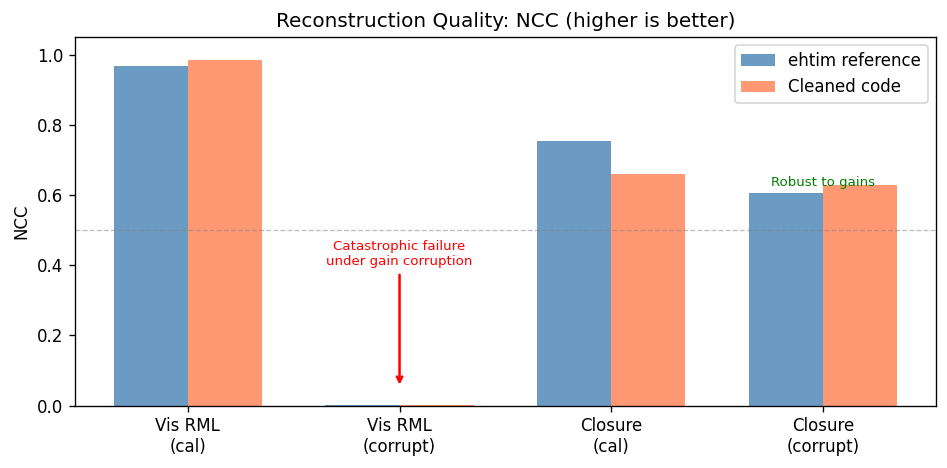

In [11]:
# Bar chart: NCC comparison
fig, ax = plt.subplots(figsize=(8, 4))

labels = ['Vis RML\n(cal)', 'Vis RML\n(corrupt)', 'Closure\n(cal)', 'Closure\n(corrupt)']
ehtim_keys = ['Vis RML (cal)', 'Vis RML (corrupt)', 'Closure-only (cal)', 'Closure-only (corrupt)']
our_keys = ['Vis RML (cal)', 'Vis RML (corrupt)', 'Closure-only (cal)', 'Closure-only (corrupt)']

ehtim_ncc = [ehtim_metrics.get(k, {}).get('ncc', 0) for k in ehtim_keys]

if os.path.exists(os.path.join(output_dir, 'metrics.json')):
    our_ncc = [our_metrics.get(k, {}).get('ncc', 0) for k in our_keys]
    x = np.arange(len(labels))
    width = 0.35
    ax.bar(x - width/2, ehtim_ncc, width, label='ehtim reference', color='steelblue', alpha=0.8)
    ax.bar(x + width/2, our_ncc, width, label='Cleaned code', color='coral', alpha=0.8)
else:
    x = np.arange(len(labels))
    ax.bar(x, ehtim_ncc, 0.5, label='ehtim reference', color='steelblue', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('NCC')
ax.set_title('Reconstruction Quality: NCC (higher is better)')
ax.legend()
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)

# Annotate the key result
ax.annotate('Catastrophic failure\nunder gain corruption',
            xy=(1, 0.05), fontsize=8, ha='center', color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            xytext=(1, 0.4))
ax.annotate('Robust to gains',
            xy=(3, ehtim_ncc[3] + 0.02), fontsize=8, ha='center', color='green')

plt.tight_layout()
plt.show()

## Key Takeaway

Closure-only imaging (**cphase + logcamp**) is robust to unknown station-based gain errors,
while traditional visibility imaging fails catastrophically. This is the core result of
Chael et al. (2018) and a key insight for the Event Horizon Telescope's imaging pipeline.

| Method | Calibrated NCC | Corrupted NCC | Robust? |
|--------|:---:|:---:|:---:|
| Vis RML | ~0.97 | ~0.00 | No |
| Closure-only | ~0.66 | ~0.63 | **Yes** |

### Implementation Notes
- Forward model uses DFT with ehtim's `+2pi*i` sign convention and triangle pulse
- Optimization in log-image space (matching ehtim's default `transform=['log']`)
- Closure phase chi-squared uses the von Mises form: `(2/N) * sum((1 - cos(delta)) / sigma^2)`
- Entropy regularizers are negated to act as penalties (ehtim convention)
- L-BFGS-B with 3 rounds of 300 iterations each